# Coursework 1
**Replace CID in the file name with your CID**

# Outline


- [Task 1](#task-1): Linear regression and feature selection <a name="index-task-1"></a>
  - [(1.1)](#task-11) <a name="index-task-11"></a>
  - [(1.2)](#task-12) <a name="index-task-12"></a>
  - [(1.3)](#task-13) <a name="index-task-13"></a>
  - [(1.4)](#task-14) <a name="index-task-14"></a>
- [Task 2](#task-2): Non-linear regression with Kernel Ridge Regression <a name="index-task-2"></a>
  - [(2.1)](#task-21) <a name="index-task-21"></a>
  - [(2.2)](#task-22)  <a name="index-task-22"></a>
- [Task 3](#task-3): Classification with the Multi-Layer Perceptron <a name="index-task-3"></a>
  - [(3.1)](#task-31) <a name="index-task-31"></a>
  - [(3.2)](#task-32)  <a name="index-task-32"></a>



---



<a name="task-1"></a>

# Task 1: Linear regression and feature selection [(index)](#index-task-1)

Before we start, let's get input and output by slicing. Then we shall standardise X_train and X_test using parameters calculated from X_train. Also degine X_train_aug for augmented matrix do deal with intercept.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.default_rng(0)

data_train = pd.read_csv('asteroid_observations_train.csv')
data_test = pd.read_csv('asteroid_observations_test.csv')


X_train = data_train.iloc[:, :7].values # convert to array type
dia_train = data_train.iloc[:, 7].values
class_train = data_train.iloc[:, 8].values

X_test = data_test.iloc[:, :7].values
dia_test = data_test.iloc[:, 7].values
class_test = data_test.iloc[:, 8].values

print(data_train.head())

def standardise(X, X_train_=None):
    """
    Standardise features.

    Parameters:
        X (np.array): Feature matrix.
        X_train_ (np.array): An optional feature matrix to compute the statistics
            from before applying it to X. If None, just use X to compute the statistics.

    Returns:
        X_std (np.array): Standardised feature matrix
    """
    if X_train_ is None:
        X_train_ = X

    mu = np.mean(X_train_, axis=0, keepdims=True)
    sigma = np.std(X_train_, axis=0, keepdims=True)
    X_std = (X - mu) / sigma

    return X_std


X_train_std = standardise(X_train)
X_test_std = standardise(X_test, X_train) #using training set to calculate mean and sd

N, p = X_train.shape
X_train_aug = np.hstack([np.ones((N,1)), X_train_std]) #standardised augmented X  N+1 * p
#print(X_train_aug.shape)

   Absolute magnitude  Albedo  Number of observations  Observation arc length  \
0                18.1   0.041                      15                     2.0   
1                12.5   0.139                     349                  7208.0   
2                14.1   0.062                     705                 25309.0   
3                16.9   0.097                      91                  3805.0   
4                11.5   0.062                    1300                  9606.0   

   Orbital eccentricity  Orbital inclination  Orbital period  \
0              0.201590            11.975800        3.912298   
1              0.032746             8.793883       11.942668   
2              0.179314            27.433960        5.749452   
3              0.066114            13.813845        4.592982   
4              0.008824             5.595907       12.006096   

   Asteroid diameter Asteroid class  
0              1.573            MBA  
1             12.355            TJN  
2             

<a name="task-11"></a>

## (1.1) [(index)](#index-task-11)

In [2]:
def compute_LSregression(X, y):
    """
    For model y = X beta, learn beta using least square regression.
    Parameter:
        X(np.array): Feature matrix N * p
        y(np.array): vector N
    Returns:
        beta learnt
    """
    assert X.shape[0] == y.shape[0], "input X and y have different length!"
    N = y.shape[0]
    X_aug = np.hstack([np.ones((N,1)), X])
    
    beta = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)
    return beta

In [3]:
beta_ls = compute_LSregression(X_train_std, dia_train)
beta_ls

array([11.83155799, -9.25892809, -3.11707348,  1.99398808,  1.37607063,
        0.34068455,  0.97216587, -0.30875842])

According to lecture 1, the contraint is mathematically equivalent to add a penalty term in our loss function

our new loss function is:
$$L(\boldsymbol g) = \frac{1}{N} \sum_{i=1}^{N} \left( y^{(i)} - \left( \sum_{j=1}^{p} g_j \beta_j^{LS} x_j^{(i)} + \beta_0^{LS} \right) \right)^2 + \lambda \sum_{i=1}^{p} |g_i|$$

However, $\sum_{i=1}^{N} |g_i|$ is not smooth, so we use Huber loss $\sum_{i=1}^p L_c(g_i)$ to replace it, where $L_c(g_i)$ is defined as:

$L_c (g_i) =
\begin{cases}
 \frac{1}{2}{g^2_i}                   & \text{for } |g_i| \le c, \\
 c (|g_i| - \frac{1}{2}c), & \text{otherwise,}
\end{cases}
$

Now we compute the gradient. Before that, we simplify loss function using matrix.
define $B = diag(\beta^{LS}_1 ... \beta^{LS}_p)$
then loss function is:
$$L(g) = \frac{1}{N} \left\| \bar{y} - (X B g + \beta_0 \mathbf{1}) \right\|^2 + \lambda \sum_{j=1}^p L_c(g_j)$$

Applying chain rule, we get
$$\nabla_g L(\boldsymbol g) = -\frac{2}{N} B X^T \left( \bar{y} - (X B g + \beta_0 \mathbf{1}) \right) + \lambda \sum_{j=1}^p \nabla L_c(g_j)$$


In [4]:
def compute_gradient(X, y, g, beta_ls, lam, c):
    N = X.shape[0]

    beta0 = beta_ls[0]
    b = beta_ls[1:]  # slopes

    y_hat = beta0 + X @ (b * g)
    residuals = y - y_hat

    grad_mse = -(2.0 / N) * (X.T @ residuals) * b

    grad_huber = np.where(np.abs(g) <= c,
                          g,
                          c * np.sign(g))

    return grad_mse + lam * grad_huber


In [5]:
def minimise_loss(X, y, lambd, n_iters=10000, step_size=1e-7, c_huber=1e-4):
    """
    Optimise g for slopes only, given a fixed LS solution beta_ls = [beta0, beta1..betap].
    Fixing beta0
    """
    p = X.shape[1]
    g = np.zeros(p)
    beta_ls = compute_LSregression(X, y)
    for i in range(n_iters):
        grad = compute_gradient(X, y, g, beta_ls, lambd, c_huber)
        g -= step_size * grad

    return g



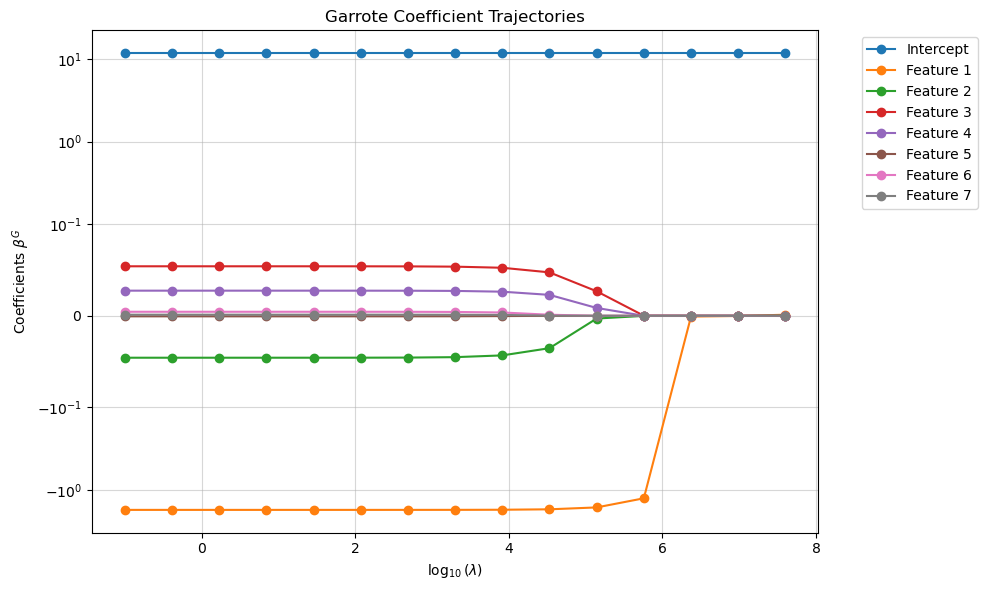

In [6]:
lambdas = np.logspace(-1, 7.6, 15)

beta_garrote_trajectories = []

# Train the Garrote method for each lambda
for lambd in lambdas:
    g_opt = minimise_loss(X_train_std, dia_train, lambd, n_iters=10000, step_size=1e-7)
    
    # Calculate Garrote coefficients: beta_G = g * beta_ls
    beta_G = beta_ls.copy()
    beta_G[1:] = beta_ls[1:] * g_opt
    beta_garrote_trajectories.append(beta_G)

beta_garrote_trajectories = np.array(beta_garrote_trajectories)

plt.figure(figsize=(10, 6))
for j in range(beta_garrote_trajectories.shape[1]):
    label = f'Feature {j}' if j > 0 else 'Intercept'
    plt.plot(np.log10(lambdas), beta_garrote_trajectories[:, j], label=label, marker='o')

plt.xlabel(r'$\log_{10}(\lambda)$')
plt.ylabel(r'Coefficients $\beta^G$')
plt.title('Garrote Coefficient Trajectories')
plt.yscale("symlog", linthresh=0.1)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Discussion
We can see Garrote has very strong ability identifying the key feature, as feature one (orange) converge to 0 much slower than all other features.
Generally, coefficients reduce size sharply as lambda increase to a shreshold.

<a name="task-12"></a>

## (1.2) [(index)](#index-task-12)

In [7]:
def cross_validation_MSE(X_train, y_train, folds, k):
  scores = []
  for i in range(len(folds)):
    val_indexes = folds[i]
    train_indexes = list(set(range(y_train.shape[0])) - set(val_indexes))


    X_train_i = X_train[train_indexes, :]
    y_train_i = y_train[train_indexes]

    X_val_i = X_train[val_indexes, :]
    y_val_i = y_train[val_indexes]

    # We standardise both training and validation sets
    X_train_i_std = standardise(X_train_i)
    X_val_i_std = standardise(X_val_i, X_train_i)

    score_i = score(X_train_i, y_train_i, X_val_i, y_val_i, k=k)
    scores.append(score_i)

  # Return the average score
  return sum(scores) / len(scores)

In [8]:
def garrote_cv(X_train_full, y_train_full, lambdas, T):
    """
    Performs T-fold cross-validation and returns stability measure D for each lambda.
    """
    N = X_train_full.shape[0]
    indices = np.arange(N)
    folds = np.array_split(indices, T)

    D_per_lambda = []

    for lambd in lambdas:
        fold_mses = []

        for i in range(T):
            val_idx = folds[i]
            train_idx = np.setdiff1d(indices, val_idx)

            X_tr, y_tr = X_train_full[train_idx], y_train_full[train_idx]
            X_val, y_val = X_train_full[val_idx], y_train_full[val_idx]

            # standardise per fold
            X_tr_std = standardise(X_tr)
            X_val_std = standardise(X_val, X_tr)

            # LS for this fold (includes intercept internally)
            beta_ls_fold = compute_LSregression(X_tr_std, y_tr)  # shape (p+1,)

            # optimise g on slopes only (NO augmented X here)
            g_opt = minimise_loss(
                X_tr_std, y_tr, lambd,
                n_iters=10000, step_size=1e-7, c_huber=1e-4
            )

            # Garrote prediction without augmenting
            beta0 = beta_ls_fold[0]
            slopes_g = beta_ls_fold[1:] * g_opt
            y_pred = beta0 + X_val_std @ slopes_g

            mse_fold = np.mean((y_val - y_pred) ** 2)
            fold_mses.append(mse_fold)

        D_lambda = np.mean(np.abs(np.diff(fold_mses)))
        D_per_lambda.append(D_lambda)

        print(f"Lambda: {lambd:.2e} | D: {D_lambda:.4f}")

    return np.array(D_per_lambda)


lambdas = np.logspace(-1, 7.6, 15)
mse_results = garrote_cv(X_train, dia_train, lambdas, 2)



Lambda: 1.00e-01 | D: 36.5325
Lambda: 4.11e-01 | D: 36.5325
Lambda: 1.69e+00 | D: 36.5325
Lambda: 6.96e+00 | D: 36.5325
Lambda: 2.87e+01 | D: 36.5326
Lambda: 1.18e+02 | D: 36.5329
Lambda: 4.85e+02 | D: 36.5342
Lambda: 2.00e+03 | D: 36.5397
Lambda: 8.21e+03 | D: 36.5622
Lambda: 3.38e+04 | D: 36.6510
Lambda: 1.39e+05 | D: 37.1140
Lambda: 5.72e+05 | D: 38.1737
Lambda: 2.35e+06 | D: 50.3644
Lambda: 9.68e+06 | D: 50.3704
Lambda: 3.98e+07 | D: 50.3899


Lambda: 1.00e-01 | D: 36.5325
Lambda: 4.11e-01 | D: 36.5325
Lambda: 1.69e+00 | D: 36.5325
Lambda: 6.96e+00 | D: 36.5325
Lambda: 2.87e+01 | D: 36.5326
Lambda: 1.18e+02 | D: 36.5329
Lambda: 4.85e+02 | D: 36.5342
Lambda: 2.00e+03 | D: 36.5397
Lambda: 8.21e+03 | D: 36.5622
Lambda: 3.38e+04 | D: 36.6510
Lambda: 1.39e+05 | D: 37.1140
Lambda: 5.72e+05 | D: 38.1737
Lambda: 2.35e+06 | D: 50.3644
Lambda: 9.68e+06 | D: 50.3704
Lambda: 3.98e+07 | D: 50.3899
Lambda: 1.00e-01 | D: 125.1673
Lambda: 4.11e-01 | D: 125.1673
Lambda: 1.69e+00 | D: 125.1673
Lambda: 6.96e+00 | D: 125.1674
Lambda: 2.87e+01 | D: 125.1677
Lambda: 1.18e+02 | D: 125.1687
Lambda: 4.85e+02 | D: 125.1728
Lambda: 2.00e+03 | D: 125.1898
Lambda: 8.21e+03 | D: 125.2596
Lambda: 3.38e+04 | D: 125.5467
Lambda: 1.39e+05 | D: 126.7141
Lambda: 5.72e+05 | D: 130.5028
Lambda: 2.35e+06 | D: 139.4382
Lambda: 9.68e+06 | D: 139.4431
Lambda: 3.98e+07 | D: 139.4564


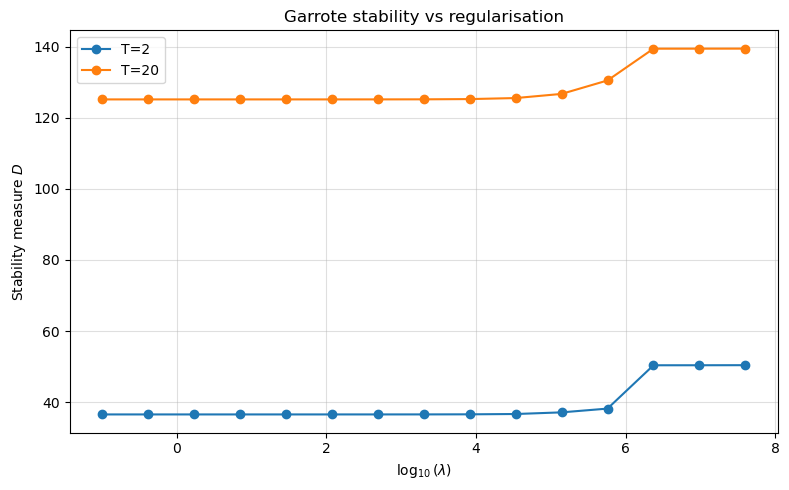

In [9]:
lambdas = np.logspace(-1, 7.6, 15)

D_T2  = garrote_cv(X_train, dia_train, lambdas, T=2)
D_T20 = garrote_cv(X_train, dia_train, lambdas, T=20)

plt.figure(figsize=(8, 5))
plt.plot(np.log10(lambdas), D_T2,  marker='o', label='T=2')
plt.plot(np.log10(lambdas), D_T20, marker='o', label='T=20')
plt.xlabel(r'$\log_{10}(\lambda)$')
plt.ylabel('Stability measure $D$')
plt.title('Garrote stability vs regularisation')
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

### Discussion
Qualitatively, for both T, increase in lambda leads to decrease in stability (larger D, more unstable). This means near-zero coefficients are more sensitive to small perturbation in data.
Larger T seems to be more unstable than small T for all values of lambda, this might because larger T has smaller sample size per folds, and the outliers would have much more effect on these folds. While for small T, larger folds absorbs such variance.

<a name="task-13"></a>

## (1.3) [(index)](#index-task-13)

In [35]:
def grad_huber(beta, c = 1e-6):
    g = np.empty_like(beta)
    return  np.where(np.abs(beta) < c, beta, c * np.sign(beta))

def compute_lasso_gradient(X_aug, y, beta, lam, c):
    """
    Computes the gradient for LASSO with Huber smoothing.
    X_aug: (N, p+1) augmented matrix with ones
    beta: (p+1,) current coefficients (beta_0 is at index 0)
    """
    N = X_aug.shape[0]
    y_hat = X_aug @ beta
    residuals = y - y_hat
    
    grad_mse = -(2/N) * X_aug.T @ residuals
    
    #Huber Gradient
    grad_pen = grad_huber(beta, c)
    grad_pen[0] = 0   # do not penalise intercept

    return grad_mse + lam * grad_pen


def minimise_lasso_loss(X, y, lambd, n_iters=10000, step_size=1e-7, c_huber=1e-4):
    beta = np.zeros(X.shape[1])
    
    for _ in range(n_iters):
        grad = compute_lasso_gradient(X, y, beta, lambd, c_huber)
        beta = beta - step_size * grad
        
    return beta

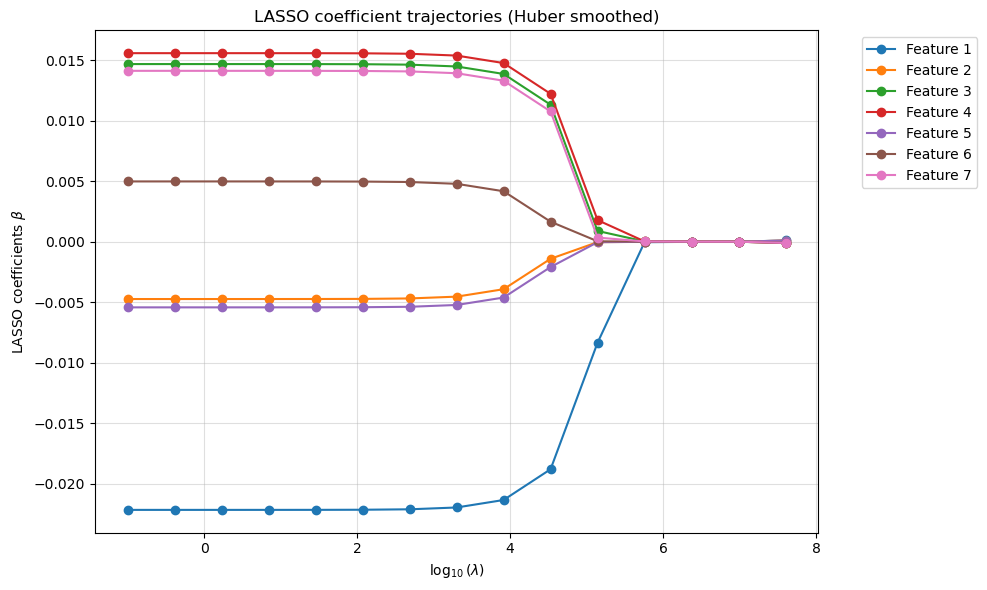

In [36]:
lambdas = np.logspace(-1, 7.6, 15)
lasso_trajectories = []

for lambd in lambdas:
    beta_lasso = minimise_lasso_loss(
        X_train_aug, dia_train, lambd,
        n_iters=10000, step_size=1e-7, c_huber=1e-4
    )
    lasso_trajectories.append(beta_lasso)

lasso_trajectories = np.array(lasso_trajectories)

plt.figure(figsize=(10, 6))
for j in range(1, lasso_trajectories.shape[1]):  # skip intercept
    plt.plot(np.log10(lambdas), lasso_trajectories[:, j], label=f'Feature {j}', marker='o')

plt.xlabel(r'$\log_{10}(\lambda)$')
plt.ylabel(r'LASSO coefficients $\beta$')
plt.title('LASSO coefficient trajectories (Huber smoothed)')
#plt.yscale("symlog", linthresh=0.1)
plt.grid(True, which="both", alpha=0.4)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Discussion
We see Lasso coefficients shrink earlier than Garrotes'(4.5 vs 6). While Garrote shrinks more proportionally. Also feature 1, 2 retains longer in Garrotes, while only feature 1 retains longer in Lasso.

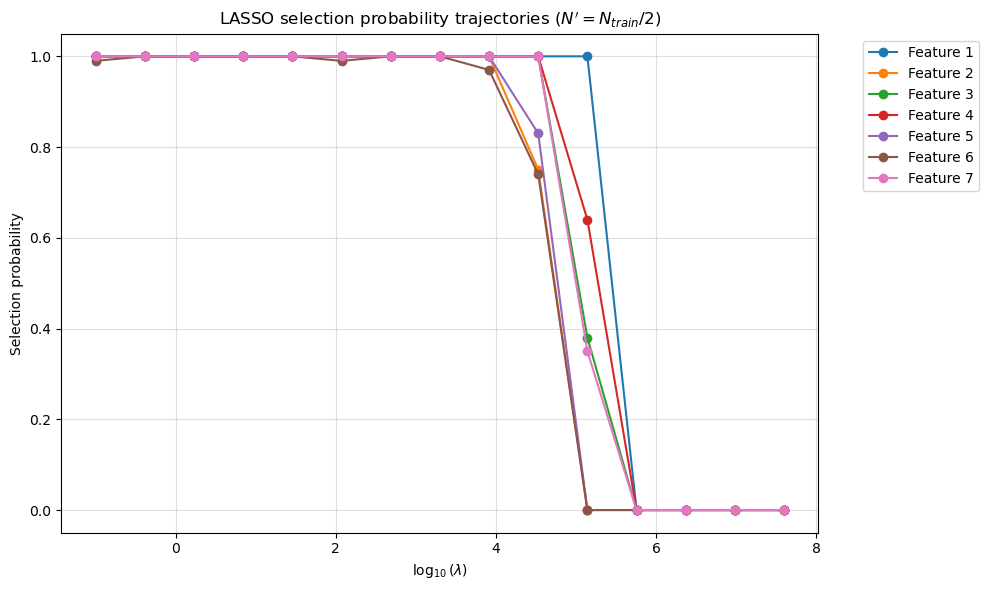

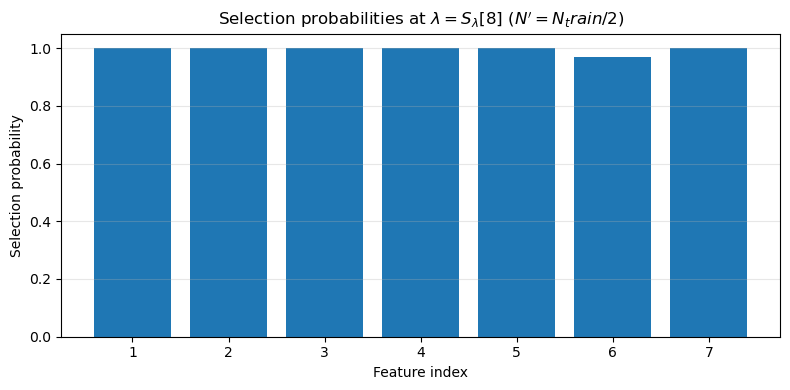

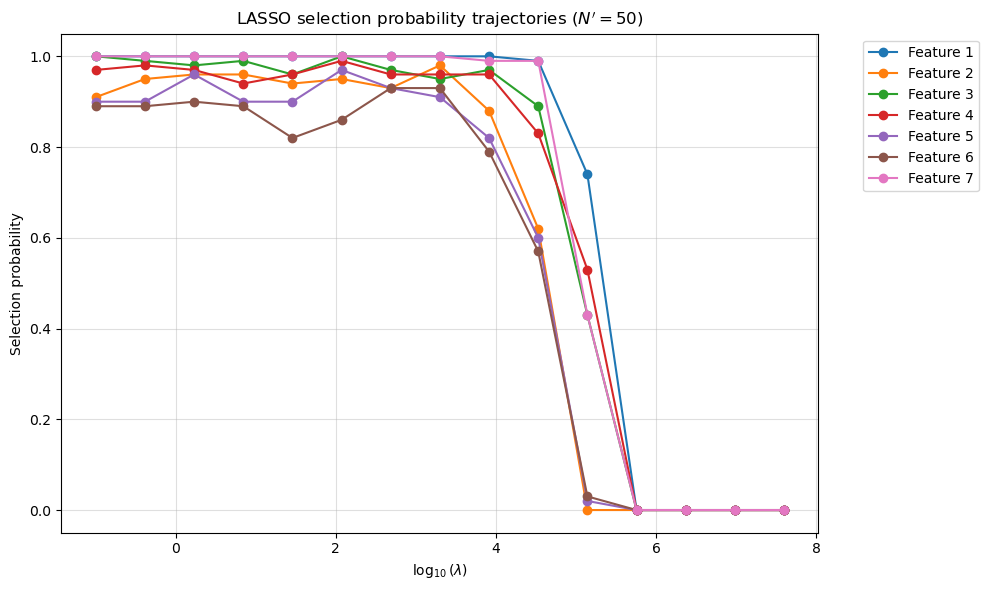

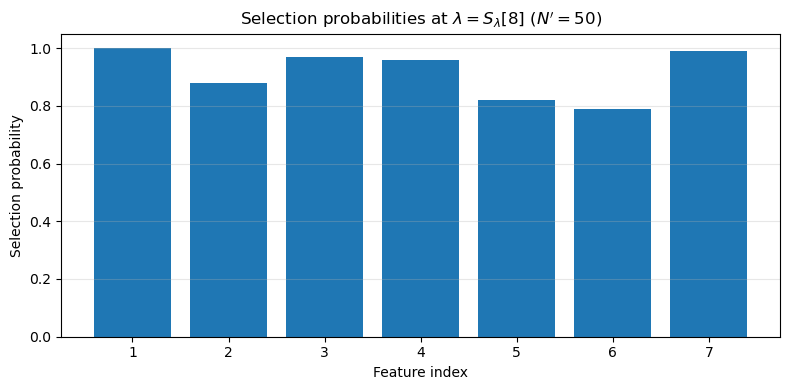

In [37]:
def selection_probabilities_lasso_bootstrap(X_train_std, y_train, lambdas, N_prime, B=100,
                                           n_iters=10000, step_size=1e-7, c_huber=1e-4,
                                           thresh=1e-3, seed=0):
    """
    Returns selection probabilities with shape (len(lambdas), p)
    """
    rng = np.random.default_rng(seed)
    N, p = X_train_std.shape
    probs = np.zeros((len(lambdas), p), dtype=float)

    for li, lam in enumerate(lambdas):
        selected_counts = np.zeros(p, dtype=float)

        for _ in range(B):
            # sample without replacement
            idx = rng.choice(N, size=N_prime, replace=False)
            X_b = X_train_std[idx]
            y_b = y_train[idx]

            # augment with intercept column
            X_b_aug = np.column_stack([np.ones(X_b.shape[0]), X_b])  # (N', p+1)

            # fit lasso
            beta_b = minimise_lasso_loss(
                X_b_aug, y_b, lam,
                n_iters=n_iters, step_size=step_size, c_huber=c_huber
            )  # shape (p+1,)

            # selection decision on slopes only
            selected_counts += (np.abs(beta_b[1:]) > thresh)

        probs[li] = selected_counts / B

    return probs


#plots
Ntrain = X_train.shape[0]
lambdas = np.logspace(-1, 7.6, 15)
loglam = np.log10(lambdas)
idx_bar = 8

probs_half = selection_probabilities_lasso_bootstrap(
    X_train_std, dia_train, lambdas, N_prime=Ntrain//2, B=100,
    n_iters=10000, step_size=1e-7, c_huber=1e-4, thresh=1e-3, seed=0
)

plt.figure(figsize=(10, 6))
for j in range(probs_half.shape[1]):
    plt.plot(loglam, probs_half[:, j], marker='o', label=f'Feature {j+1}')
plt.xlabel(r'$\log_{10}(\lambda)$')
plt.ylabel('Selection probability')
plt.title(r"LASSO selection probability trajectories ($N^\prime = N_{train}/2$)")
plt.grid(True, alpha=0.4)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(np.arange(1, probs_half.shape[1] + 1), probs_half[idx_bar])
plt.xlabel('Feature index')
plt.ylabel('Selection probability')
plt.title(rf"Selection probabilities at $\lambda = S_\lambda[8]$ ($N^\prime = N_train/2$)")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#N = 50
probs_50 = selection_probabilities_lasso_bootstrap(
    X_train_std, dia_train, lambdas, N_prime=50, B=100,
    n_iters=10000, step_size=1e-7, c_huber=1e-4, thresh=1e-3, seed=0
)

plt.figure(figsize=(10, 6))
for j in range(probs_50.shape[1]):
    plt.plot(loglam, probs_50[:, j], marker='o', label=f'Feature {j+1}')
plt.xlabel(r'$\log_{10}(\lambda)$')
plt.ylabel('Selection probability')
plt.title(r"LASSO selection probability trajectories ($N^\prime = 50$)")
plt.grid(True, alpha=0.4)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(np.arange(1, probs_50.shape[1] + 1), probs_50[idx_bar])
plt.xlabel('Feature index')
plt.ylabel('Selection probability')
plt.title(rf"Selection probabilities at $\lambda = S_\lambda[8]$ ($N^\prime = 50$)")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Discussion
For large samples : N' = Ntrain / 2, all features have selection probability close to 1 for smaller value of lambda.
But as lambda increase to a threshold, the probability sharply drops towards 0. so overall this model is stable.

For smaller samples: N' = 50, we see probability for different features aren't close to 1 even for smaller value of lambda, since smaller samples induce more noises. And the transition to 0 is more gradual, indicating less stability.

<a name="task-14"></a>

## (1.4) [(index)](#index-task-14)

In [38]:
# Augment with intercept
X_train_aug = np.hstack([np.ones((X_train_std.shape[0], 1)), X_train_std])
X_test_aug  = np.hstack([np.ones((X_test_std.shape[0], 1)), X_test_std])

# Fit OLS
beta_ols = np.linalg.solve(X_train_aug.T @ X_train_aug,
                           X_train_aug.T @ dia_train)


In [40]:
def r2_score(y, y_hat):
    """R^2 score to assess regression performance."""

    # Adjustment to avoid subtraction between (K,) and (1, K) arrays.
    y = y.reshape(y_hat.shape)
    y_bar = y.mean()

    ss_tot = ((y - y_bar)**2).sum()
    ss_res = ((y - y_hat)**2).sum()
    return 1 - (ss_res/ss_tot)

y_pred_test = X_test_aug @ beta_ols
baseline_r2 = r2_score(dia_test, y_pred_test)

print("Baseline R²:", baseline_r2)


Baseline R²: 0.7362124940498773


In [41]:
rng = np.random.default_rng(0)
p = X_test_std.shape[1]

importances = []

for j in range(p):
    X_test_perm = X_test_std.copy()
    
    # Permute only column j
    X_test_perm[:, j] = rng.permutation(X_test_perm[:, j])
    
    X_test_perm_aug = np.hstack([np.ones((X_test_perm.shape[0], 1)), 
                                  X_test_perm])
    
    y_pred_perm = X_test_perm_aug @ beta_ols
    r2_perm = r2_score(dia_test, y_pred_perm)
    
    importance = baseline_r2 - r2_perm
    importances.append(importance)

importances = np.array(importances)


In [42]:
max_imp = np.max(importances)
importance_pct = 100 * importances / max_imp


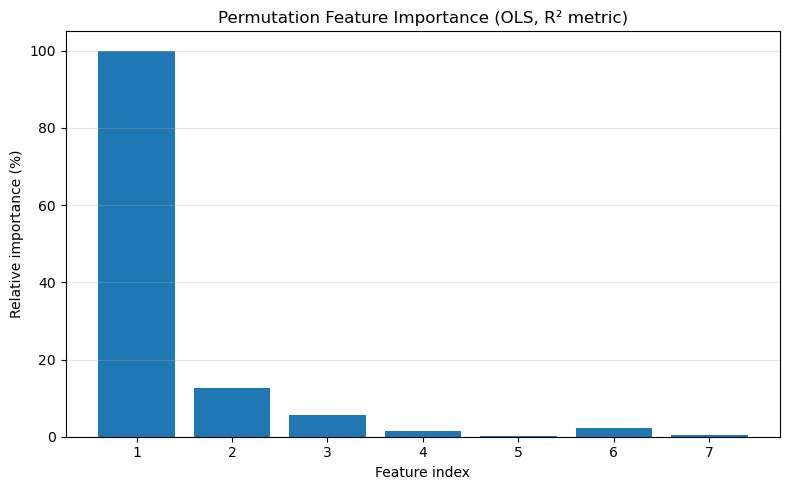

In [43]:
plt.figure(figsize=(8,5))
plt.bar(np.arange(1, p+1), importance_pct)
plt.xlabel("Feature index")
plt.ylabel("Relative importance (%)")
plt.title("Permutation Feature Importance (OLS, R² metric)")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Discussion
feature 1 (absolute magnitude) appears to have highest relative importance, this actually aligns with selection probability graph in 1.3, in which selection probability for feature 1 is the last one starts to drop, it stick to 1 for widest range of lambda. Also, looking at lasso coefficients graph from 1.1, the coefficient associate wiht feature 1 is the last one converge to 0, confirms its dominates position.

<a name="task-2"></a>

# Task 2: Non-linear regression with Kernel Ridge Regression [(index)](#index-task-2)

<a name="task-21"></a>

## (2.1) [(index)](#index-task-21)

rewrite the loss function: 

$$
L(\beta) = \frac{1}{N} \|y - X\beta\|^2 + \lambda \|\beta\|^2,
$$
first train ordinary ridge regression

In [44]:
def ridge_estimate(X, y, penalty):

    # X: N x p matrix of training inputs
    # y: N x 1 vector of training targets/observations
    # returns: maximum likelihood parameters ((p + 1) x 1)

    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape
    X_aug = np.hstack([np.ones((N,1)), X]) # augmented training inputs of size N x (p + 1)
    N_aug, p_aug = X_aug.shape
    I = np.identity(p_aug)
    I[0] = 0.0 # penalty excludes the bias term.
    beta_ridge = np.linalg.solve(X_aug.T @ X_aug + penalty * I, X_aug.T @ y)
    return beta_ridge

In [45]:
def fit_ridge_with_intercept(X, y, lam=0.1):
    """
    Minimizes (1/N)||y - (Xb + b0)||^2 + lam||b||^2
    Intercept b0 is NOT regularized.
    """
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)

    N, p = X.shape

    # center
    X_mean = X.mean(axis=0)
    y_mean = y.mean()
    Xc = X - X_mean
    yc = y - y_mean

    A = Xc.T @ Xc + (N * lam) * np.eye(p)
    b = np.linalg.solve(A, Xc.T @ yc)

    # recover intercept
    b0 = y_mean - X_mean @ b
    return b, b0

def predict_ridge(X, b, b0):
    return np.asarray(X) @ b + b0

def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res/ss_tot if ss_tot > 0 else 0.0


lam = 0.1
b, b0 = fit_ridge_with_intercept(X_train_std, dia_train, lam=lam)

ytr = predict_ridge(X_train_std, b, b0)
yte = predict_ridge(X_test_std,  b, b0)

print("Ridge (linear) λ=0.1")
print("Train R2:", r2_score(dia_train, ytr))
print("Test  R2:", r2_score(dia_test,  yte))


Ridge (linear) λ=0.1
Train R2: 0.750465814764694
Test  R2: 0.7460360911430929


### KRR Formulation
Now we fit formulate the kernelised ridge regression, we use kernel trick to only deal with transformed dot product, so here we introduce vector u:


$$
X\beta = X X^T u.
$$

Define the kernel matrix

$$
K = X X^T,
\quad K_{ij} = x^{(i)T} x^{(j)}.
$$

Then

$$
X\beta = Ku.
$$

The regularization term becomes

$$
\|\beta\|^2 =
\beta^T \beta =
(X^T u)^T (X^T u) =
u^T K u.
$$

Substituting into the loss yields the kernelized Ridge regression loss:

$$ L(u) =
\frac{1}{N}
\|y - Ku\|^2
+
\lambda u^T K u.
$$


### Analytical solution
Now we derive analytical solution of Kernel Ridge Regression

We start from the kernel ridge regression loss:

$$
L(u) =
\frac{1}{N}\|y - Ku\|^2
+
\lambda u^T K u,
$$

First expand:

$$
\|y - Ku\|^2 =
(y - Ku)^T (y - Ku)
$$

Since the kernel matrix is symmetric ($K^T = K$):

$$
L(u) =
\frac{1}{N}
(y^T y - 2 y^T Ku + u^T K^2 u)
+
\lambda u^T K u.
$$


Using matrix derivatives:

$$
\nabla_u (u^T A u) = 2Au,
\quad
\nabla_u (b^T u) = b,
$$

we obtain

$$
\nabla L(u) =
\frac{1}{N}
(-2Ky + 2K^2 u)
+
2\lambda Ku. =
2K
\left(
\frac{1}{N}(Ku - y)
+
\lambda u
\right).
$$

Now we set to 0 and solve

$$
\frac{1}{N}(Ku - y)
+
\lambda u =
0.
$$

Multiplying by $N$:

$$
Ku - y + N\lambda u = 0.
$$

$$
(K + N\lambda I)u = y.
$$

Therefore, the analytical solution is

$$
u = (K + N\lambda I)^{-1} y.
$$


In [46]:
def polynomial_kernel(X, Z, n=2, c=1):
    """
    Compute polynomial kernel matrix between X and Z.

    X: (N, d)
    Z: (M, d)
    returns: (N, M) kernel matrix
    """
    return (X @ Z.T + c) ** n


In [47]:
def train_poly_krr(X_train, y_train, lam=0.1, n=2, c=1):
    """
    Train Kernel Ridge Regression.

    returns:
        u: dual coefficients
        X_train: stored for prediction
    """
    K = polynomial_kernel(X_train, X_train, n=n, c=c)

    N = K.shape[0]
    u = np.linalg.solve(K + N * lam * np.eye(N), y_train)

    return u


In [48]:
def predict_poly_krr(X_test, u, X_train, n=2, c=1):
    """
    Predict outputs for test data.
    """
    K_test = polynomial_kernel(X_test, X_train, n=n, c=c)
    return K_test @ u


In [49]:
def evaluate_krr_models(X_train, y_train, X_test, y_test):
    configs = [
        {"n": 2, "c": 0},
        {"n": 2, "c": 1},
        {"n": 3, "c": 1},
    ]

    results = []

    for cfg in configs:
        u = train_poly_krr(
            X_train, y_train,
            lam=0.1,
            n=cfg["n"],
            c=cfg["c"]
        )

        y_train_pred = predict_poly_krr(X_train, u, X_train, cfg["n"], cfg["c"])
        y_test_pred  = predict_poly_krr(X_test,  u, X_train, cfg["n"], cfg["c"])

        r2_train = r2_score(y_train, y_train_pred)
        r2_test  = r2_score(y_test,  y_test_pred)

        results.append((cfg, r2_train, r2_test))

    return results

results = evaluate_krr_models(X_train_std, dia_train, X_test_std, dia_test)

for cfg, r2_tr, r2_te in results:
    print(cfg, "Train R2:", r2_tr, "Test R2:", r2_te)



{'n': 2, 'c': 0} Train R2: 0.7442772950233129 Test R2: 0.6175788574986585
{'n': 2, 'c': 1} Train R2: 0.9532555877132627 Test R2: 0.947743591512433
{'n': 3, 'c': 1} Train R2: 0.9843306895540662 Test R2: 0.9759929264269636


### Discussion:
comparing with ordinary regression, with: 
Train R2: 0.750465814764694
Test  R2: 0.7460360911430929
Ordinary regression assumes a linear model, which might not be the actual model.
We see that increase in n and c increase score for both tran and test data, since kernelised regression allows fit to non-linear model, and increase in n c increase complexity and interpretability of the model. 

<a name="task-22"></a>

## (2.2) [(index)](#index-task-22)


===== lambda = 0.1 =====
Polynomial train R2: 0.950370


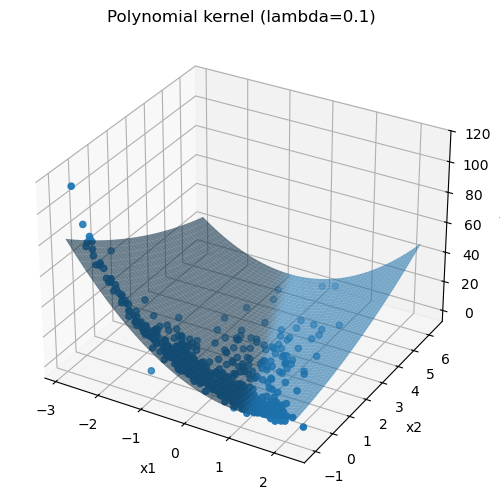

RBF train R2: 0.421963


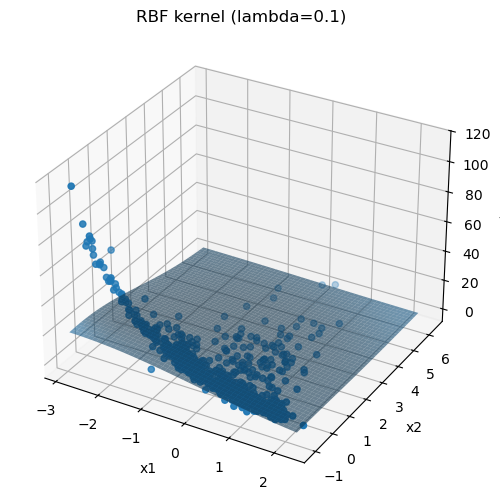

New train R2: 0.396055


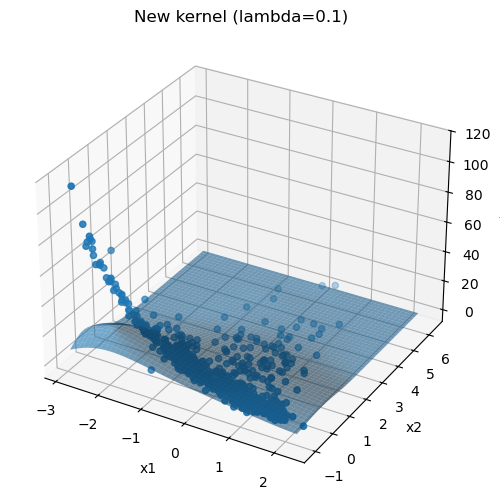


===== lambda = 300 =====
Polynomial train R2: -0.745609


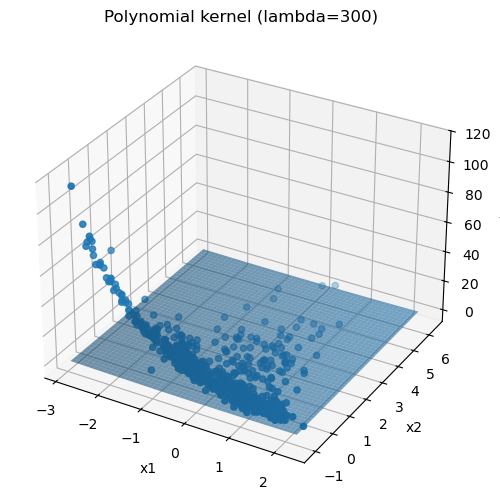

RBF train R2: -0.780351


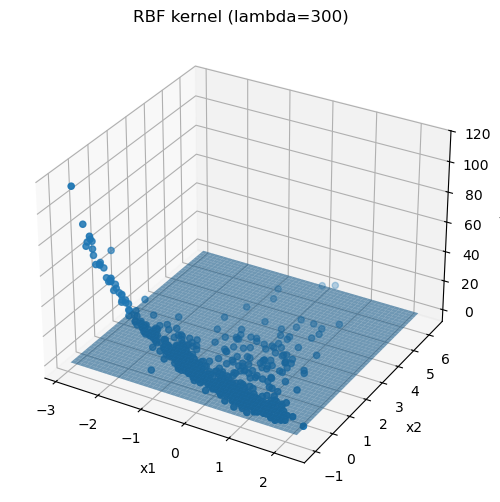

New train R2: -0.782037


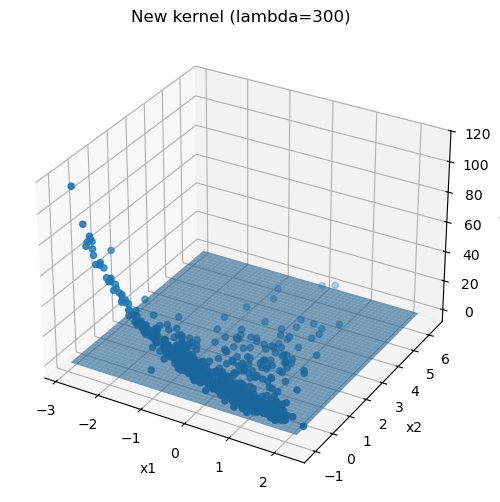

In [51]:
# restrict features & restandardise
Xs_train = X_train[:, :2]
Xs_test  = X_test[:, :2]

Xs_train_std = standardise(Xs_train)
Xs_test_std  = standardise(Xs_test, Xs_train)


# kernels
def poly_kernel(X, Z):
    return (X @ Z.T + 1.0) ** 2

def rbf_kernel(X, Z, sigma=20.0):
    X_sq = np.sum(X**2, axis=1, keepdims=True)
    Z_sq = np.sum(Z**2, axis=1, keepdims=True).T
    dist_sq = X_sq + Z_sq - 2.0 * (X @ Z.T)
    return np.exp(-dist_sq / sigma)

def new_kernel(X, Z, sigma=20.0):
    # k_new(v,z) = exp( -||phi(v)-phi(z)||^2 / sigma )
    Kxz = poly_kernel(X, Z)
    Kxx = np.diag(poly_kernel(X, X))
    Kzz = np.diag(poly_kernel(Z, Z))
    dist_sq = Kxx[:, None] + Kzz[None, :] - 2.0 * Kxz
    return np.exp(-dist_sq / sigma)


#train and predict functions
def train_krr(X, y, kernel_func, lam):
    y = np.asarray(y).reshape(-1)
    K = kernel_func(X, X)
    N = K.shape[0]
    u = np.linalg.solve(K + (N * lam) * np.eye(N), y)
    return u

def predict_krr(X, X_train, u, kernel_func):
    return kernel_func(X, X_train) @ u


def plot_krr_surface(X, y, u, kernel_func, title):
    x1, x2 = X[:, 0], X[:, 1]
    gx1, gx2 = np.meshgrid(
        np.linspace(x1.min(), x1.max(), 50),
        np.linspace(x2.min(), x2.max(), 50)
    )
    grid = np.column_stack([gx1.ravel(), gx2.ravel()])
    y_grid = predict_krr(grid, X, u, kernel_func).reshape(gx1.shape)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(x1, x2, y, label="Train data")
    ax.plot_surface(gx1, gx2, y_grid, alpha=0.6)
    ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
    ax.set_title(title)
    plt.show()


kernels = [("Polynomial", poly_kernel), ("RBF", rbf_kernel), ("New", new_kernel)]

for lam in [0.1, 300]:
    print(f"\n===== lambda = {lam} =====")
    for name, kernel in kernels:
        u = train_krr(Xs_train_std, dia_train, kernel, lam)
        yhat = predict_krr(Xs_train_std, Xs_train_std, u, kernel)
        print(f"{name} train R2: {r2_score(dia_train, yhat):.6f}")

        plot_krr_surface(
            Xs_train_std, dia_train, u, kernel,
            f"{name} kernel (lambda={lam})"
        )


### Discussion
as shown in graph, for small lambda, polynomial kernel fit the data best, while RBF and new kernel fit poorly. This is due to the fact that the data is has more polynomial-like structure, as shown in the surface plotted.
for lambda = 300, this almost completely dominate the penalty term, giving too big bias, thus the underfitting for all three kernels.

<a name="task-3"></a>

# Task 3: Classification with the Multi-Layer Perceptron [(index)](#index-task-3)

In [52]:
# acquire one-hot class values
class_dict = {'MBA' : 0, 'OMB' : 1, 'TJN' : 2}


def to_one_hot(class_labels, class_dict):
    """
    Convert string class labels to one-hot encoding.
    """
    N = len(class_labels)
    classes = np.arange(3)
    class_labels = np.array(class_labels)

    # Convert strings → indices
    indices = np.array([class_dict[label] for label in class_labels])

    # Create one-hot matrix
    one_hot = np.zeros((N, 3))
    one_hot[np.arange(N), indices] = 1

    return one_hot
oclass_train = to_one_hot(class_train, class_dict)
oclass_test = to_one_hot(class_test, class_dict)

<a name="task-31"></a>

## (3.1) [(index)](#index-task-31)

For this question, we build MLP as we did in lecture notebook, write error back propagatoin. Then define Cross-Entropy loss function, after that we did minibatch sgd and record celoss for some epochs, thus generate the graph

In [53]:
def dense(X, W, b):
    """Full-connected MLP layer.

    Parameters:
        X (np.ndarray): K x h_in array of inputs, where K is the batch size and h_in is the input dimension.
        W (np.ndarray): h_out x h_in array for weights matrix parameters, where h_out is the output dimension.
        b (np.ndarray): Length h_out 1-D array for bias parameters

    Returns:
        a (np.ndarray): K x h_out array of pre-activations
    """
    a = np.vstack([W @ x + b for x in X]) ## <-- SOLUTION
    return a

def relu_activation(a):
    """ReLU activation function.

    Parameters:
        a: K x h_out array of pre-activations

    Returns:
        h: K x h_out array of post-activations
    """
    # compute post-activations
    h = np.maximum(a, 0.)  ## <-- SOLUTION
    return h

def grad_relu_activation(a):
    """Gradient of ReLU activation function.

    Parameters:
        a: K x h_out array of pre-activations

    Returns:
        grad: K x h_out gradient array of post-activations
    """
    # compute gradient
    grad = np.zeros_like(a) ## <-- SOLUTION
    grad[a>0] = 1 ## <-- SOLUTION
    return grad
activation_table = {
    "relu": relu_activation,
    "identity": lambda x: x
}

# A lookup table for gradient of activation functions by their names.
grad_activation_table = {
    "relu": grad_relu_activation,
    "identity": lambda x: np.ones_like(x)
}

class MLP:
    """
    This class represents a Multi-Layer Perceptron (MLP), that we are going
    to use to encapsulate two components:
        1. layers: the sequence of layers, where each layer is stored in
            a dictionary in the format {"W": np.ndarray, "b": np.ndarray},
            where "W" points to the weights array, and "b" points to
            the bias vector.
        2. rng: a pseudo random number generator (RNG) initialised to generate
            the random weights in a reproducible manner between different
            runtime sessions.
    This class is also shipped with methods that perform essential operations
    with a MLP, including:
        - add_layers: which creates a new layer with specified dimensions.
        - predict: applies the MLP forward pass to make predictions and produces
            a computational graph for the forward pass that can be used to
            compute gradients using backpropagation algorithm.
        in addition to other light functions that return simple statistics about
        the MLP.
    """
    def __init__(self, seed=42):
        self.layers = []
        self.rng = np.random.default_rng(seed)

    def n_parameters(self):
        """Return the total number of parameters of weights and biases."""
        return sum(l["b"].size + l["W"].size for l in self.layers)

    def n_layers(self):
        """Return current number of MLP layers (including input and output)."""
        return len(self.layers) + 1 if len(self.layers) > 0 else 0

    def layer_dim(self, index):
        """Retrieve the dimensions of the MLP layer at `index`."""
        return self.layers[index]["W"].shape

    def add_layer(self, in_dim, out_dim, activation="identity"):
        """Add fully connected layer to MLP.

        Parameters:
            in_dim (int): The input dimension of the layer.
            out_dim (int): The output dimension of the layer.
            activation (str): The activation function name.
        """
        # check if input-dimension matches output-dimension of previous layer
        if self.n_layers() > 0:
            last_out_dim, _ = self.layer_dim(-1)
            assert in_dim == last_out_dim, f"Input-dimension {in_dim} does not match output-dimension {last_out_dim} of previous layer."

        # the first layer, in our convention illustrated, does not apply activation on the input features X.
        if self.n_layers() == 0:
            assert activation == "identity", "Should not apply activations on the input features X, use Identity function for the first layer."


        # store each layer as a dictionary in the list, as shown in the
        # attached diagram.
        self.layers.append({
            # only for debugging.
            "index": len(self.layers),
            # apply Glorot initialisation for weights.
            # hint: use self.rng.normal()
            "W": self.rng.normal(size=(out_dim, in_dim)) * np.sqrt(2. / (in_dim + out_dim)), ## <-- SOLUTION
            # initialise bias vector with zeros.
            "b": np.zeros(out_dim), ## <-- SOLUTION
            # store the activation function (as string)
            "activation": activation
        })

    def predict(self, X):
        """Apply the forward pass on the input X and produce prediction and the
        forward computation graph.

        Parameters:
            X (np.ndarray): Feature matrix.

        Returns:
            (np.ndarray, List[Dict[str, np.ndarray]]): A tuple of the
            predictions and the computation graph as a sequence of intermediate
            values through the MLP, specifically each layer will have a corresponding
            intermediate values {"a": np.ndarray, "h": np.ndarray}, as shown in the
            attached diagram above.
        """
        # We assume that we work with a batch of examples (ndim==2).
        if X.ndim == 1:
            # If one example passed, add a dummy dimension for the batch.
            X = X.reshape(1, -1)

        # store pre- and post-activations in list
        forward_pass = [{"index": 0, "a": X, "h": X}]

        # iterate through hidden layers
        for k in range(1, len(self.layers)):
            # compute pre-activations
            a = dense(forward_pass[k - 1]["h"], self.layers[k - 1]["W"], self.layers[k - 1]["b"]) ## <-- SOLUTION
            activation = activation_table[self.layers[k]["activation"]] ## <-- SOLUTION
            forward_pass.append({"index": k, "a" : a, "h" : activation(a)})

        y_hat = dense(forward_pass[-1]["h"], self.layers[-1]["W"], self.layers[-1]["b"]) ## <-- SOLUTION
        # predicted target is output of last layer
        return y_hat, forward_pass

def backpropagate(layers, forward_pass, delta_output):
    """
    Apply the backpropagation algorithm to the MLP layers to compute the gradients starting from
    the output layer to the input layer, and starting the chain rule from the
    partial derivative of the loss function w.r.t the predictions $\hat{y}$

    Parameters:
        layers (List[Dict[str, np.ndarray]]): The MLP sequence of layers, as shown in the diagrams.
        forward_pass (List[Dict[str, np.ndarray]]): The forward pass intermediate values for
            each layer, representing a computation graph.
        delta_output (np.ndarray): the partial derivative of the loss function w.r.t the
            predictions $\hat{y}$, has the shape (K, 1), where K is the batch size.
    Returns:
        gradients (List[Dict[str, np.ndarray]]): The computed gradient using a structure symmetric in the layers, as shown
            in the diagrams.

    """
    # Create a list that will contain the gradients of all the layers.
    gradients = []

    # Initialise delta.
    delta = delta_output

    assert len(layers) == len(forward_pass), "Number of layers is expected to match the number of forward pass layers"

    # Iterate on layers backwardly, from output to input.
    # Calculate gradients w.r.t. weights and biases of each level and store in list of dictionaries.
    for layer, forward_computes in reversed(list(zip(layers, forward_pass))):   # zip iterates through pairs of layers and forward_pass
        assert forward_computes["index"] == layer["index"], "Mismatch in the index."

        h = forward_computes["h"]
        assert delta.shape[0] == h.shape[0], "Mismatch in the batch dimension."

        # Gradients are average gradients over batch
        gradients.append({"W" : (delta.T @ h) / h.shape[0], # <-- SOLUTION
                          "b" : delta.mean(axis=0)}) # <-- SOLUTION

        # Update the delta for the next iteration
        grad_activation_f = grad_activation_table[layer["activation"]]
        grad_activation = grad_activation_f(forward_computes["a"])

        # Calculate the delta for the backward layer.
        delta = np.stack([np.diag(gi) @ layer["W"].T @ di
                           for (gi, di) in zip(grad_activation, delta)]) # <-- SOLUTION.


    # Return now ordered list matching the layers.
    gradients = list(reversed(gradients))
    return gradients

In [54]:
mlp = MLP(seed=2)
mlp.add_layer(7, 64)
mlp.add_layer(64, 64, "relu")
mlp.add_layer(64, 32, "relu")
mlp.add_layer(32, 3, "relu")

In [55]:
def softmax(a):
    """
    softmax
    a: N * 3
    returns: softmax
    """
    exp_a = np.exp(a)

    # sum over classes, keeps row structure
    sum_a = np.sum(exp_a, axis=1, keepdims=True)

    return exp_a / sum_a


In [56]:
y_hat = mlp.predict(X_train_std)[0]
p = softmax(y_hat)

In [57]:
def ce_loss(y, a):
    """
    cross entropy loss

    Parameters
        y : np.ndarray
            One-hot labels, shape (N, 3).
        a : np.ndarray
            Pre-activations (logits), shape (N, 3).

    Returns
        cross entropy loss
    """

    p = softmax(a)
    return -np.sum(y * np.log(p)) / y.shape[0]

def grad_ce_loss(y, a):
    """
    Gradient of cross-entropy loss w.r.t. logits (a).

    Parameters:
        y : np.ndarray
            One-hot labels, shape (N, 3).
        a : np.ndarray
            Logits (pre-activations), shape (N, 3).
    Returns
        grad : np.ndarray
            Gradient dL/da, shape (N, 3).
    """

    p = softmax(a)
    N = y.shape[0]
    grad = (p - y)

    return grad


In [58]:
def sgd_step(X, y, mlp, learning_rate = 1e-3):
    """
    Apply a stochastic gradient descent step using the sampled batch.
    Parameters:
        X (np.ndarray): The input features array batch, with dimension (K, p).
        y (np.ndarray): The ground-truth of the batch, with dimension (K, 1).
        learning_rate (float): The learning rate multiplier for the update steps in SGD.
    Returns:
        updated_layers (List[Dict[str, np.ndarray]]): The updated layers after applying SGD.
    """
    # Compute the forward pass.
    y_hat, forward_pass = mlp.predict(X) ## <-- SOLUTION.

    # Compute the partial derivative of the loss w.r.t. to predictions `y_hat`.
    delta_output = grad_ce_loss(y, y_hat) ## <-- SOLUTION

    # Apply backpropagation algorithm to compute the gradients of the MLP parameters.
    gradients = backpropagate(mlp.layers, forward_pass, delta_output)  ## <-- SOLUTION.

    # mlp.layers and gradients are symmetric, as shown in the figure.
    updated_layers = []
    for layer, grad in zip(mlp.layers, gradients):
        W = layer["W"] - learning_rate * grad["W"] ## <-- SOLUTION.
        b = layer["b"] - learning_rate * grad["b"] ## <-- SOLUTION.
        updated_layers.append({"W": W, "b": b,
                               # keep the activation function.
                               "activation": layer["activation"],
                               # We use the index for asserts and debugging purposes only.
                               "index": layer["index"]})
    return updated_layers

def sgd(X_train, y_train, X_test, y_test, mlp, learning_rate = 1e-3,
        n_epochs=10, minibatchsize=1, seed=42, plot_losses = False):
    """
    Run the Stochastic Gradient Descent (SGD) algorithm to optimise the parameters of MLP model to fit it on
    the training data using MSE loss.

    Parameters:
        X_train (np.ndarray): The training data features, with shape (N^{training}, p).
        y_train (np.ndarray): The training data ground-truth, with shape (N^{training}, 1).
        X_test (np.ndarray): The testing data features, with shape (N^{test}, p).
        y_test (np.ndarray): The testing data ground-truth, with shape (N^{test}, 1).
        mlp (MLP): The MLP object enacpsulating the MLP model.
        learning_rate (float): The learning_rate multiplier used in updating the parameters at each iteration.
        n_epochs (int): The number of training cycles that each covers the entire training examples.
        minibatchsize (int): The batch size used in each SGD step.
        seed (int): A seed for the RNG to ensure reproducibility across runtime sessions.

    Returns:
        mlp (MLP): MLP object encapuslating the trained MLP model.
        losses_train (np.ndarray): Train losses over epochs.
        losses_tset (np.ndarray): Test losses over epochs.
    """

    # get random number generator
    rng = np.random.default_rng(seed)

    # compute number of iterations per epoch
    n_iterations = int(len(y_train) / minibatchsize)

    # store losses
    losses_train = []
    losses_test = []

    for i in range(n_epochs):

        # shuffle data
        p = rng.permutation(len(y_train))
        X_train_shuffled = X_train[p]
        y_train_shuffled = y_train[p]

        for j in range(n_iterations):
            # get batch
            X_batch = X_train_shuffled[j*minibatchsize : (j+1)*minibatchsize]
            y_batch = y_train_shuffled[j*minibatchsize : (j+1)*minibatchsize]

            # apply sgd step
            updated_layers = sgd_step(X_batch, y_batch, mlp, learning_rate) ## <-- SOLUTION.

            # update weights and biases of MLP
            mlp.layers = updated_layers ## <-- SOLUTION.

        # compute loss at the end of each epoch
        y_hat_train, _ = mlp.predict(X_train)
        loss_train = ce_loss(y_train, y_hat_train).squeeze()
        losses_train.append(loss_train)
        y_hat_test, _ = mlp.predict(X_test)
        loss_test = ce_loss(y_test, y_hat_test).squeeze()
        losses_test.append(loss_test)


    if plot_losses:
            epochs = np.arange(1, n_epochs + 1)

            plt.figure()
            plt.plot(epochs, losses_train, label="train loss")
            plt.plot(epochs, losses_test, label="test loss")
            plt.xlabel("Epoch")
            plt.ylabel("Cross-Entropy Loss")
            plt.title("Loss vs Epochs")
            plt.legend()
            plt.grid(True)
            plt.show()

    return mlp, losses_train, losses_test


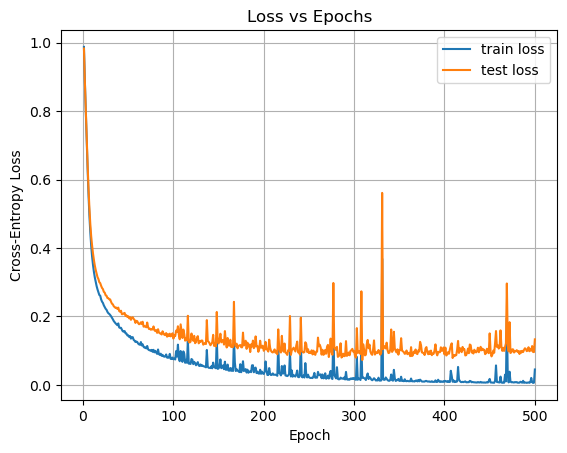

500

In [59]:
mlp, losses_train, losses_test = sgd(X_train_std, oclass_train, X_test_std, oclass_test,
                                     mlp, learning_rate = 0.04,
                                     n_epochs=500,
                                     minibatchsize=64, plot_losses = True)
len(losses_train)

### Discussion
From the graph we see both train loss and test loss converge rapidly for the first 50 epochs, then eventually stabilise.
also, train loss stabilise around a lower ce loss than test loss, this indicates a mild overfitting, but within tolerable margin.

Next we look at the spikes on the graph, they are mainly casued by mini-batch = 1, sometimes a unexpected gradient will be given.
Also, we noticed that the spikes seem to overlap, at the same epoch and similar height. This is because we are using one model and this confirms the spikes are due to unexpected gradient.

In [60]:
# Forward pass
logits_test, _ = mlp.predict(X_test_std)
p_test = softmax(logits_test)

# Predicted class indices
y_pred = np.argmax(p_test, axis=1)

# True class indices (from one-hot)
y_true = np.argmax(oclass_test, axis=1)


In [61]:
accuracy = np.mean(y_pred == y_true)
print(f"Overall test accuracy: {accuracy:.4f}")


Overall test accuracy: 0.9375


In [62]:
n_classes = 3
per_class_acc = []

for q in range(n_classes):
    idx_q = (y_true == q)
    acc_q = np.mean(y_pred[idx_q] == q)
    per_class_acc.append(acc_q)
    print(f"Accuracy for class {q}: {acc_q:.4f}")


Accuracy for class 0: 0.9623
Accuracy for class 1: 0.8596
Accuracy for class 2: 1.0000


p_test shape: (160, 3)
row sums (first 5): [1. 1. 1. 1. 1.]
min/max: 5.755328267738572e-28 1.0


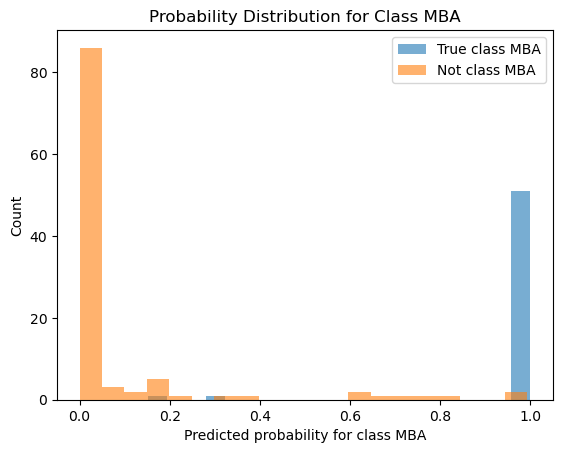

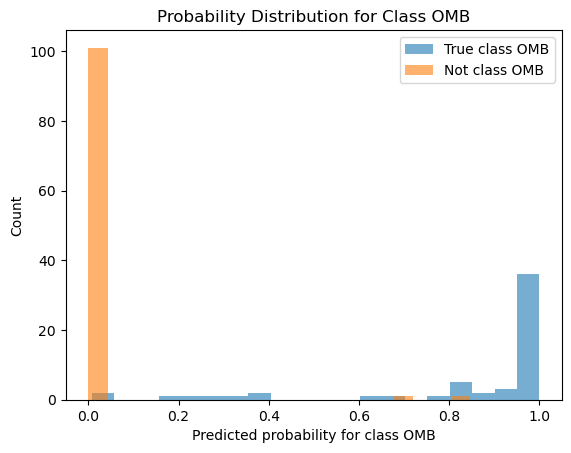

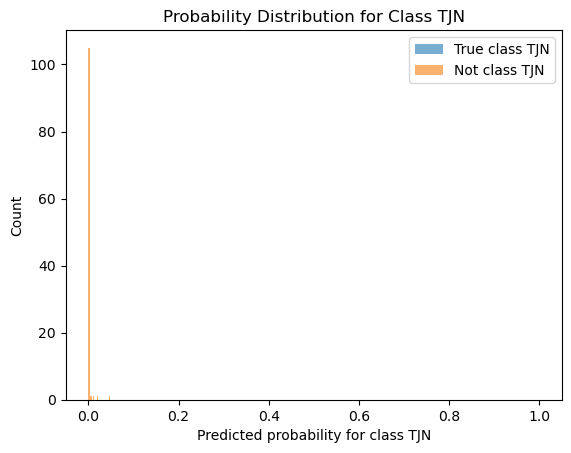

In [63]:
class_names = ["MBA", "OMB", "TJN"]
print("p_test shape:", p_test.shape)
print("row sums (first 5):", p_test[:5].sum(axis=1))
print("min/max:", p_test.min(), p_test.max())
for q in range(n_classes):

    # Probabilities for class q
    p_q = p_test[:, q]

    # Indices
    idx_true_q = (y_true == q)
    idx_not_q = (y_true != q)

    # Plot
    plt.figure()

    plt.hist(p_q[idx_true_q], bins=20, alpha=0.6, label=f"True class {class_names[q]}")
    plt.hist(p_q[idx_not_q], bins=20, alpha=0.6, label=f"Not class {class_names[q]}")

    plt.xlabel(f"Predicted probability for class {class_names[q]}")
    plt.ylabel("Count")
    plt.title(f"Probability Distribution for Class {class_names[q]}")
    plt.legend()
    plt.show()


### Discussion
metrics are:
Class 0 (MBA): 0.9623
Class 1 (OMB): 0.8596
Class 2 (TJN): 1.0000

For MBA, the ACC is high, from histogram we see there is occassionally intermediate values, causing uncertainty.

For OMB, we see from histogram there is more spread and some overlap with non-OMB samples.
Some OMB examples receive lower predicted probabilities, indicating confusion with another class.

For TJN, the model achieves 100% accuracy, due to the fact that it is highly separable from other features.

In [64]:
np.mean(p_test[y_true == 1, 1])


np.float64(0.8476151308018364)

<a name="task-32"></a>

## (3.2) [(index)](#index-task-32)

In this question, we use MLP as weak learners to perform gradient boosting. As required, we need to define sgd step to minimise mse rather than ce.
For each boosting iteration, we compute negative gradient of ce loss, then we train weak MLP to approximate the residual, finally we update the logits.

In [65]:

def grad_mse_loss(y, y_hat):
    return 2.0 * (y_hat - y)

def sgd_step_mse(X, y, mlp, learning_rate=1e-3):
    # forward
    y_hat, forward_pass = mlp.predict(X)
    # dL/dy_hat
    delta_output = grad_mse_loss(y, y_hat)
    # backprop
    gradients = backpropagate(mlp.layers, forward_pass, delta_output)
    # update
    updated_layers = []
    for layer, grad in zip(mlp.layers, gradients):
        updated_layers.append({
            "W": layer["W"] - learning_rate * grad["W"],
            "b": layer["b"] - learning_rate * grad["b"],
            "index": layer["index"],
            "activation": layer["activation"],
        })
    mlp.layers = updated_layers
    return mlp

def sgd_mse(X_train, y_train, mlp, learning_rate=1e-3, n_epochs=10, minibatchsize=32, seed=42):
    rng = np.random.default_rng(seed)
    N = X_train.shape[0]
    for _ in range(n_epochs):
        perm = rng.permutation(N)
        for i in range(0, N, minibatchsize):
            idx = perm[i:i+minibatchsize]
            Xb = X_train[idx]
            yb = y_train[idx]
            mlp = sgd_step_mse(Xb, yb, mlp, learning_rate=learning_rate)
    return mlp

def per_class_accuracy(y_true_idx, y_pred_idx, n_classes=3):
    accs = []
    for q in range(n_classes):
        mask = (y_true_idx == q)
        accs.append(np.mean(y_pred_idx[mask] == q))
    return accs

a_train, _ = mlp.predict(X_train_std)   # logits from 3.1 model
a_test,  _ = mlp.predict(X_test_std)

# True class indices (from one-hot)
y_true_test = np.argmax(oclass_test, axis=1)

M = 4 # number of weak models
nu = 2
lr = 0.05
epochs = 1000
bs = 32
seed = 42

print("Initial strong model performance:")
p_test = softmax(a_test)
y_pred = np.argmax(p_test, axis=1)
accs = per_class_accuracy(y_true_test, y_pred, n_classes=3)
for q, acc in enumerate(accs):
    print(f"  ACC class {q}: {acc:.4f}")

weak_models = []

# Boosting iterations
for m in range(1, M+1):
    p_train = softmax(a_train)
    residual = oclass_train - p_train

    # Train weak model using MSE
    weak = MLP(seed=2)
    weak.add_layer(7, 32)
    weak.add_layer(32, 32, "relu")
    weak.add_layer(32, 16, "relu")
    weak.add_layer(16, 3, "identity")   # last hidden is identity per spec

    weak = sgd_mse(X_train_std, residual, weak,
                   learning_rate=lr, n_epochs=epochs, minibatchsize=bs, seed=seed)

    weak_models.append(weak)

    # Predict weak corrections and update logits
    delta_train, _ = weak.predict(X_train_std)
    delta_test,  _ = weak.predict(X_test_std)

    a_train = a_train + nu * delta_train
    a_test  = a_test  + nu * delta_test

    # Evaluate on test after this iteration
    p_test = softmax(a_test)
    y_pred = np.argmax(p_test, axis=1)
    accs = per_class_accuracy(y_true_test, y_pred, n_classes=3)

    print(f"\nBoosting interation {m}:")
    for q, acc in enumerate(accs):
        print(f"  ACC class {q}: {acc:.4f}")


Initial strong model performance:
  ACC class 0: 0.9623
  ACC class 1: 0.8596
  ACC class 2: 1.0000

Boosting interation 1:
  ACC class 0: 0.9623
  ACC class 1: 0.8596
  ACC class 2: 1.0000

Boosting interation 2:
  ACC class 0: 0.9623
  ACC class 1: 0.8596
  ACC class 2: 1.0000

Boosting interation 3:
  ACC class 0: 0.9623
  ACC class 1: 0.8772
  ACC class 2: 1.0000

Boosting interation 4:
  ACC class 0: 0.9623
  ACC class 1: 0.9123
  ACC class 2: 1.0000


In [66]:
print("Overall accuracy:", np.mean(y_pred == y_true_test))


Overall accuracy: 0.95625


### Discussion
By adding more weak models, accuracy for class 0 2 reamins same, while that for class 1 progressively increase.
Because the weak learner focus on miss-classified examples, class 1 have most of that examples. So accuracy for class 1 increase while other 2 remain stable.
